<center>

# Group: 6
# Dataset: Fast Food Consumption & Health Impact Dataset
</center>

## Choosing a Data Set, Reading in CSV, and Data Cleaning & Explanatory Data Analysis

In [ ]:
#install matplotlib and scripy
import sys
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install scipy

In [1]:
#standard imports for data science
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

#formatting
pd.set_option('display.max_columns', None)

In [2]:
#load the dataset 
df = pd.read_csv('../Data/fast_food_consumption_health_impact_dataset.csv')
print(f'shape: {df.shape}')
print(df.head())

shape: (800, 11)
   Age  Gender  Fast_Food_Meals_Per_Week  Average_Daily_Calories   BMI  \
0   56    Male                         1                    3153  28.4   
1   46    Male                        12                    1748  22.8   
2   32  Female                         8                    3020  21.5   
3   25  Female                         6                    2621  26.8   
4   38  Female                        14                    2260  18.1   

   Physical_Activity_Hours_Per_Week  Sleep_Hours_Per_Day  Energy_Level_Score  \
0                               4.5                  7.8                   9   
1                               9.6                  6.7                   2   
2                               4.0                  7.4                   2   
3                               8.4                  6.1                   6   
4                               1.9                  7.7                   7   

  Digestive_Issues  Doctor_Visits_Per_Year  Overall_Healt

In [3]:
#previous block only prints the head i.e the first 6 elements
#here is the entire dataset as data frame 
print(df)

     Age  Gender  Fast_Food_Meals_Per_Week  Average_Daily_Calories   BMI  \
0     56    Male                         1                    3153  28.4   
1     46    Male                        12                    1748  22.8   
2     32  Female                         8                    3020  21.5   
3     25  Female                         6                    2621  26.8   
4     38  Female                        14                    2260  18.1   
..   ...     ...                       ...                     ...   ...   
795   40    Male                         6                    3244  29.6   
796   31   Other                         0                    2352  24.9   
797   41   Other                        11                    2466  18.3   
798   19    Male                         8                    3047  27.9   
799   43  Female                        14                    1741  22.3   

     Physical_Activity_Hours_Per_Week  Sleep_Hours_Per_Day  \
0                        

In [4]:
#useful information regarding the dataframe created by the CSV
print(df.info())
print('\n')
#descriptive statistics 
print(df.describe()) #no rounding
print('\n')
print(df.describe().round(2)) #rounding

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               800 non-null    int64  
 1   Gender                            800 non-null    object 
 2   Fast_Food_Meals_Per_Week          800 non-null    int64  
 3   Average_Daily_Calories            800 non-null    int64  
 4   BMI                               800 non-null    float64
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64
 6   Sleep_Hours_Per_Day               800 non-null    float64
 7   Energy_Level_Score                800 non-null    int64  
 8   Digestive_Issues                  800 non-null    object 
 9   Doctor_Visits_Per_Year            800 non-null    int64  
 10  Overall_Health_Score              800 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 68.9+ KB
None


      

In [5]:
#Categorical statistics 
print('Gender Distribution')
print(df['Gender'].value_counts())
print(f'\n{(df["Gender"].value_counts(normalize=True) * 100).round(1).astype(str) + "%"}') #normalize the data i.e 0.00 -> 1.0

print('\nDigestive Issues Distribution')
print(df['Digestive_Issues'].value_counts())
print(f'\n{(df["Digestive_Issues"].value_counts(normalize=True) * 100).round(1).astype(str) + "%"}')

Gender Distribution
Gender
Male      385
Female    381
Other      34
Name: count, dtype: int64

Gender
Male      48.1%
Female    47.6%
Other      4.2%
Name: proportion, dtype: object

Digestive Issues Distribution
Digestive_Issues
No     497
Yes    303
Name: count, dtype: int64

Digestive_Issues
No     62.1%
Yes    37.9%
Name: proportion, dtype: object


In [6]:
#Handling null values
missing_count = df.isnull().sum() #null value counter
missing_pct = (df.isnull().mean()*100).round(2) #percentage of entire dataset which is null

missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct}) #visualize nulls as a df of its own
print(missing_df)

                                  Missing Count  Missing %
Age                                           0        0.0
Gender                                        0        0.0
Fast_Food_Meals_Per_Week                      0        0.0
Average_Daily_Calories                        0        0.0
BMI                                           0        0.0
Physical_Activity_Hours_Per_Week              0        0.0
Sleep_Hours_Per_Day                           0        0.0
Energy_Level_Score                            0        0.0
Digestive_Issues                              0        0.0
Doctor_Visits_Per_Year                        0        0.0
Overall_Health_Score                          0        0.0


*_No missing values were detected across the 11 columns and 800 rows. No further manipulation needed at this time to standardize missing values._*

In [7]:
#handling duplicate values
n_duplicates = df.duplicated().sum() #duplicate value counter 
print(f'Duplicate rows found: {n_duplicates}')

Duplicate rows found: 0


*_No duplicate rows detected all entries are unique_*

In [8]:
#handling outliers 
numeric_cols = [
   'Age', 'Fast_Food_Meals_Per_Week', 'Average_Daily_Calories',
   'BMI', 'Physical_Activity_Hours_Per_Week', 'Sleep_Hours_Per_Day',
   'Energy_Level_Score', 'Doctor_Visits_Per_Year', 'Overall_Health_Score' 
]
records = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out   = int(((df[col] < lower) | (df[col] > upper)).sum())
    records.append({'Column': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                    'Lower Bound': lower, 'Upper Bound': upper, 'Outliers': n_out})
    
    
outlier_df = pd.DataFrame(records).set_index('Column')
print(outlier_df.round(2))
    
    
    

                                       Q1       Q3     IQR  Lower Bound  \
Column                                                                    
Age                                 29.00    49.00   20.00        -1.00   
Fast_Food_Meals_Per_Week             3.00    11.00    8.00        -9.00   
Average_Daily_Calories            2084.75  3049.00  964.25       638.38   
BMI                                 22.50    30.62    8.12        10.31   
Physical_Activity_Hours_Per_Week     2.40     7.40    5.00        -5.10   
Sleep_Hours_Per_Day                  5.20     7.70    2.50         1.45   
Energy_Level_Score                   3.00     7.00    4.00        -3.00   
Doctor_Visits_Per_Year               3.00     9.00    6.00        -6.00   
Overall_Health_Score                 3.00     7.00    4.00        -3.00   

                                  Upper Bound  Outliers  
Column                                                   
Age                                     79.00         0  


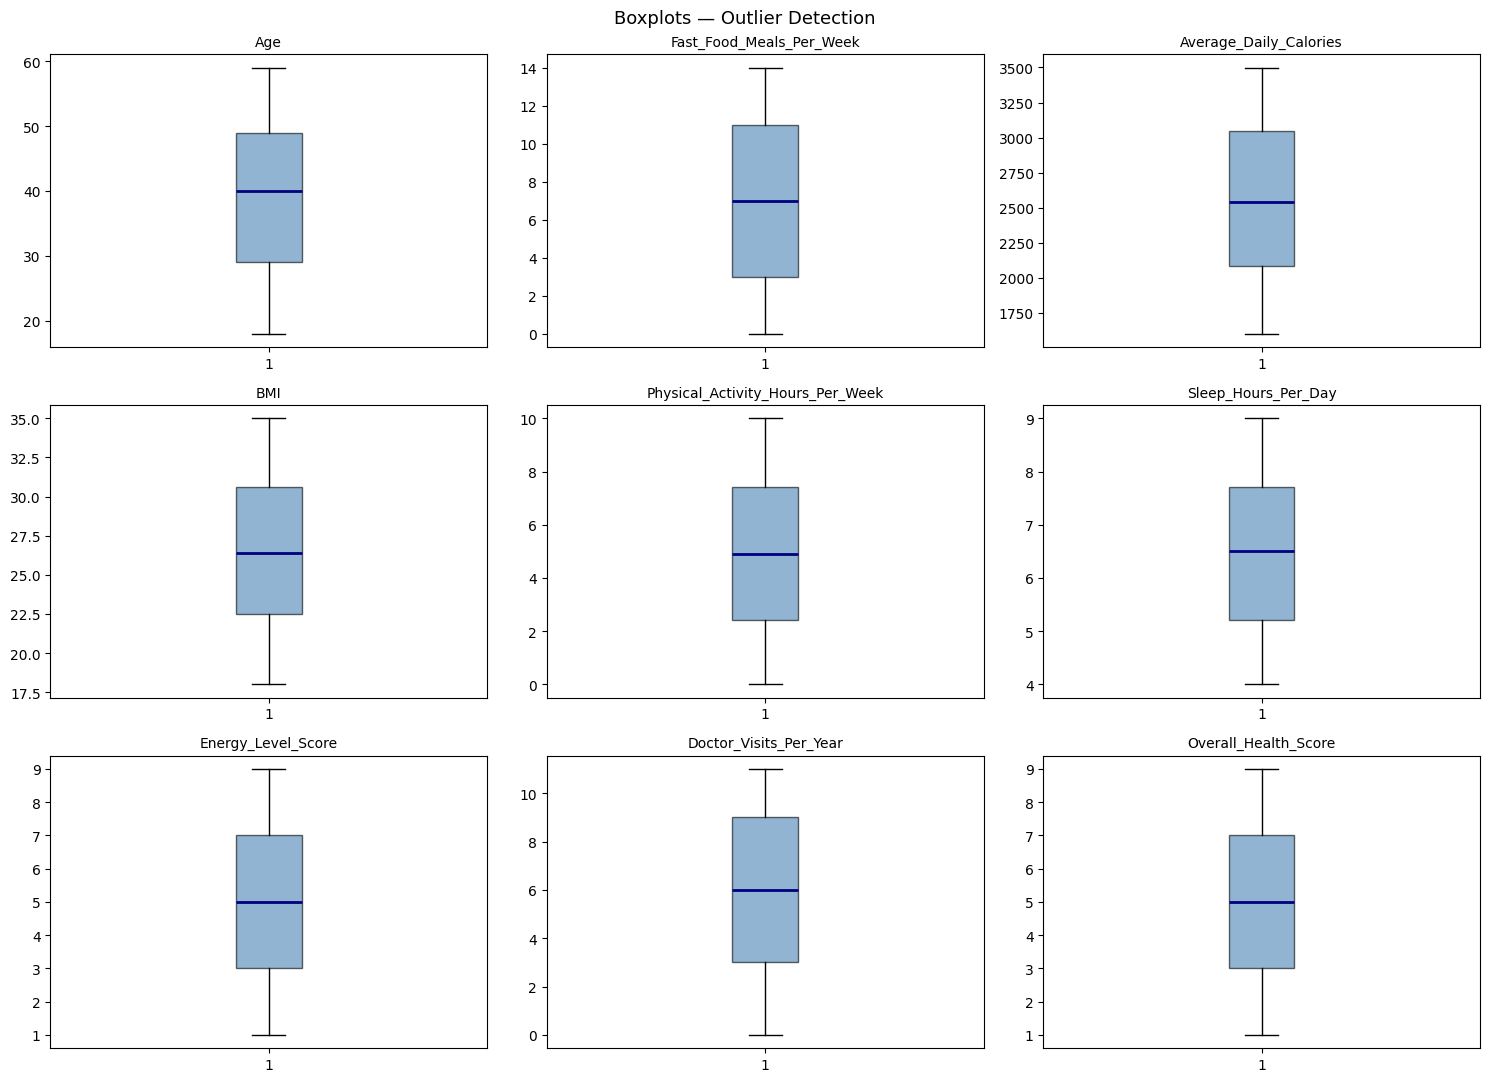

In [9]:
#For the purposes of visualizing the outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), numeric_cols):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
plt.suptitle('Boxplots — Outlier Detection', fontsize=13)
plt.tight_layout()
plt.show()

_*Based on the IQR there are not entries that fall outside the normal bounds for an adult given the data provided, No entries removed.*_

In [10]:
#group-by manipulations

#By gender
print('=== Avg Health Metrics by Gender ===')
print(df.groupby('Gender')[['BMI', 'Average_Daily_Calories',
                             'Fast_Food_Meals_Per_Week',
                             'Overall_Health_Score',
                             'Doctor_Visits_Per_Year']].mean().round(2))

#By fast food combined with doctor visits -> Digestive issues cause
print('=== Fast Food & Doctor Visits by Digestive Issues ===')
print(df.groupby('Digestive_Issues')[['Fast_Food_Meals_Per_Week',
                                      'Doctor_Visits_Per_Year',
                                      'Overall_Health_Score']].agg(['mean', 'std']).round(2))


#By age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 29, 39, 49, 60],
                          labels=['18-29', '30-39', '40-49', '50-59'])

print('=== Health Score by Age Group ===')
print(df.groupby('Age_Group', observed=True)['Overall_Health_Score'].describe().round(2))

print('\n=== Fast Food Meals/Week by Age Group ===')
print(df.groupby('Age_Group', observed=True)['Fast_Food_Meals_Per_Week'].mean().round(2))

=== Avg Health Metrics by Gender ===
          BMI  Average_Daily_Calories  Fast_Food_Meals_Per_Week  \
Gender                                                            
Female  26.47                 2577.20                      6.93   
Male    26.48                 2526.99                      6.73   
Other   25.57                 2617.03                      6.62   

        Overall_Health_Score  Doctor_Visits_Per_Year  
Gender                                                
Female                  4.96                    5.55  
Male                    4.94                    5.75  
Other                   4.41                    5.59  
=== Fast Food & Doctor Visits by Digestive Issues ===
                 Fast_Food_Meals_Per_Week       Doctor_Visits_Per_Year        \
                                     mean   std                   mean   std   
Digestive_Issues                                                               
No                                   7.05  4.39           

## Statistical Analysis & Hypothesis Testing
<center>

### Analysis Preformed: Correlation Test for Numerical Features

</center>

====== Results ======
Correlation coefficient:0.0373
p-val:0.2924


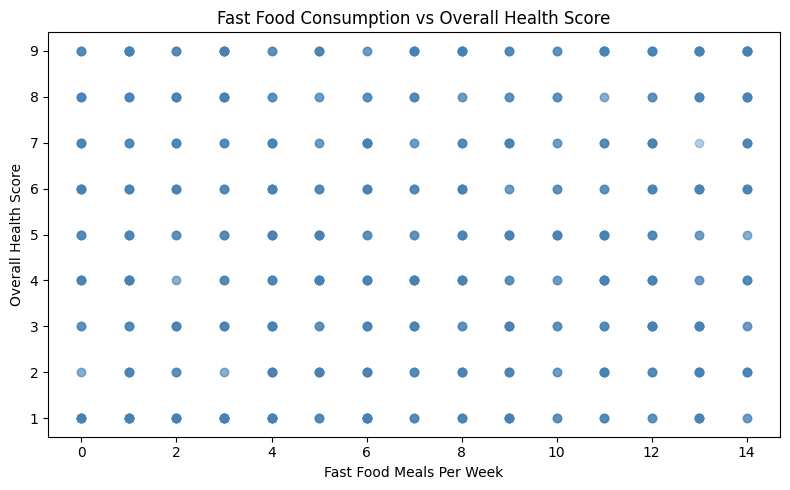

In [11]:
# stats
from scipy import stats

# the features we want to find correlation with
corr_coef, p_value = stats.pearsonr(df['Fast_Food_Meals_Per_Week'], df['Overall_Health_Score'])

# p-val(probability) and correlation coefficient -> between -1,1
print("====== Results ======")
print(f'Correlation coefficient:{corr_coef:.4f}')
print(f'p-val:{p_value:.4f}')
print("=====================")


# Visualizing as a scatter plot 
plt.figure(figsize=(8, 5))
plt.scatter(df['Fast_Food_Meals_Per_Week'], df['Overall_Health_Score'],alpha=0.4, color='steelblue')
plt.xlabel('Fast Food Meals Per Week')
plt.ylabel('Overall Health Score')
plt.title('Fast Food Consumption vs Overall Health Score')
plt.tight_layout()
plt.show()

### Pearson Correlation

*Original Question:* Is there a significant linear relationship between fast food consumption and overall health score?

*Null Hypothesis ($H_0$) :* There is NO linear correlation between fast food meals per week and overall health score ($r=0$).

*Why is this test? :* Both variables are numeric and continuous. Pearson Correlation measures the strength and direction of the linear relationship between the specified variables.

*Results:* $r = 0.0373$ ,$p = 0.2924$

*Interpretation:* Based on the calulcated correlation coefficient of 0.0373, there shows to be very little relationship/correlation between fast food consumption and overall heatlh score. The correlation coefficent is not near 1 or -1 so it indicates little correlation. 

Based on the calculated p-value of 0.2924 and the alpha level of 0.05, the calculated p-value shows to be greater than the alpha level so we fail to reject $H_0$ and can state that there is no linear correlation between fast food consumption and overall health score. 


<center>

### Analysis Preformed: T-Test

</center>

====== Results ======
t-statistic: -1.9435
p-value:0.0524


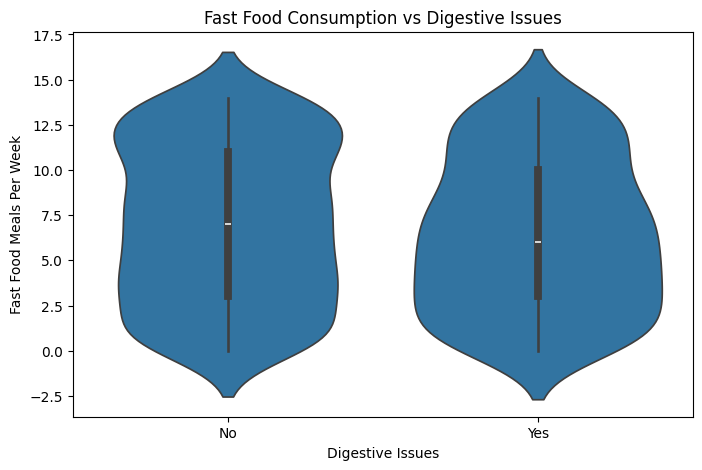

In [28]:
from scipy import stats 
import seaborn as sns

# groups (yes or no)
group_yes = df[df['Digestive_Issues'] == 'Yes']['Fast_Food_Meals_Per_Week']
group_no = df[df['Digestive_Issues'] == 'No']['Fast_Food_Meals_Per_Week']

# results calculations
#t_stat, p_value = stats.ttest_ind(group_yes, group_no)
t_stat, p_value = stats.ttest_ind(group_yes, group_no, equal_var=False)
# results yielded
print("====== Results ======")
print(f't-statistic: {t_stat:.4f}')
print(f'p-value:{p_value:.4f}')
print("=====================")

plt.figure(figsize=(8,5))

sns.violinplot(
    x='Digestive_Issues',
    y='Fast_Food_Meals_Per_Week',
    data=df
)

plt.title('Fast Food Consumption vs Digestive Issues')
plt.xlabel('Digestive Issues')
plt.ylabel('Fast Food Meals Per Week')

plt.show()

### Independent T-Test

*Original Question:* Do people with digestive issues eat more fast food than those without?

*Null Hypothesis ($H_0$) :* There is no difference in fast food consumption between individuals with and without digestive issues.

*Why is this test?:* T test is chosen to see if there is any causation between digestive issues and the amount of fast food meals eaten. 

*Results:* $t = -1.9239$, $p = 0.0547$

*Interpretation:* With the p-value being 0.0547 and the alpha level being 0.05, the p-valaue calulated shows to be greater than the significance level, thus we fail to reject the $H_0$ and can say that there is no significant difference in fast food consumption between individuals  with and without digestive issues. 

Based on the t test statistic, t = -1.9239, the negative statistic indicates that there is causation between fast food consumption and digestive issues. This t statistic shows that group_yes (people with digestuive issues) have slightly lower fast food consumption than group_no (people wihtout digestve issues)

Although the t statistic suggests there is causation between digestive issues and fast food consumption, the data still shows it is not statistically signicant. 
